In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
num_cities = 50
cities = np.random.rand(num_cities, 2) * 100  # 0-100 arası rastgele sehir koordinatlari

def distance(route):
    """Bir turun toplam mesafesi"""
    dist = 0
    for i in range(len(route)):
        dist += np.linalg.norm(route[i] - route[(i+1)%len(route)])
    return dist

def plot_route(route, title, line_color='blue'):
    """Turu görselleştir ve mesafeyi title'a ekle"""
    route = np.array(route)
    total_dist = distance(route)
    
    plt.figure(figsize=(6,6))
    plt.plot(route[:,0], route[:,1], '-', color=line_color, linewidth=2)
    plt.plot([route[-1,0], route[0,0]], [route[-1,1], route[0,1]], '-', color=line_color, linewidth=2)
    plt.scatter(route[:,0], route[:,1], color='red', s=50, zorder=5)
    plt.title(f"{title}\nToplam Mesafe: {total_dist:.2f}")
    plt.axis('equal') 
    plt.show()

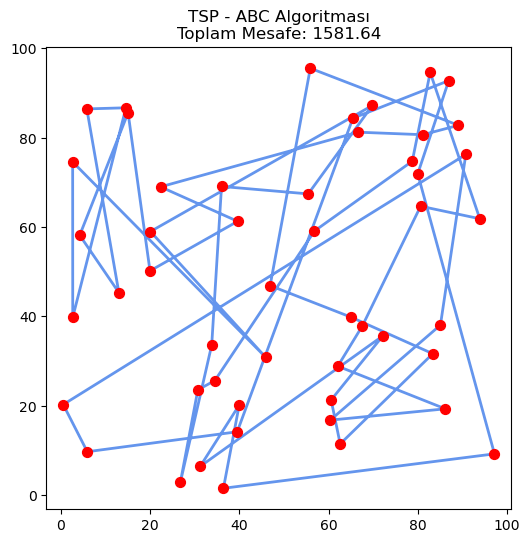

In [3]:
# Abc algoritmasi

class ABC_TSP:
    def __init__(self, cities, num_bees=30, max_iter=100):
        self.cities = cities
        self.num_bees = num_bees
        self.max_iter = max_iter
        self.num_cities = len(cities)
        
    def initialize(self):
        """Rastgele turlar oluştur"""
        population = []
        for _ in range(self.num_bees):
            route = np.arange(self.num_cities)
            np.random.shuffle(route)
            population.append(route)
        return np.array(population)
    
    def fitness(self, route):
        return 1 / distance(self.cities[route])
    
    def neighbor(self, route):
        a, b = np.random.choice(len(route), 2, replace=False)
        route[a], route[b] = route[b], route[a]
        return route
    
    def optimize(self):
        population = self.initialize()
        best_route = population[0].copy()
        best_fit = self.fitness(best_route)
        
        for it in range(self.max_iter):
            for i in range(self.num_bees):
                new_route = self.neighbor(population[i].copy())
                if self.fitness(new_route) > self.fitness(population[i]):
                    population[i] = new_route
                if self.fitness(population[i]) > best_fit:
                    best_route = population[i].copy()
                    best_fit = self.fitness(best_route)
        return best_route

# Gorsellestirme
abc_solver = ABC_TSP(cities)
best_abc = abc_solver.optimize()
plot_route(cities[best_abc], "TSP - ABC Algoritması", line_color='cornflowerblue')

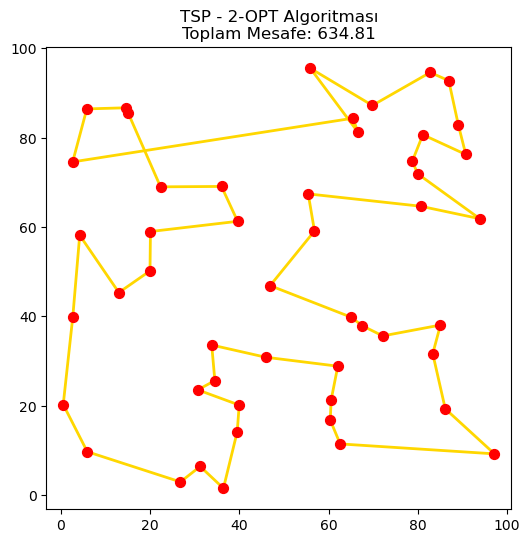

In [4]:
# 2-opt

def two_opt(route, cities, max_iter=1000):
    best = route.copy()
    improved = True
    iteration = 0
    while improved and iteration < max_iter:
        improved = False
        for i in range(1, len(best)-2):
            for j in range(i+1, len(best)):
                if j-i == 1: continue
                new_route = best.copy()
                new_route[i:j] = best[j-1:i-1:-1]
                if distance(cities[new_route]) < distance(cities[best]):
                    best = new_route
                    improved = True
        iteration += 1
    return best

# gorsellestirme
initial_route = np.arange(num_cities)
np.random.shuffle(initial_route)
best_2opt = two_opt(initial_route, cities)
plot_route(cities[best_2opt], "TSP - 2-OPT Algoritması", line_color='gold')

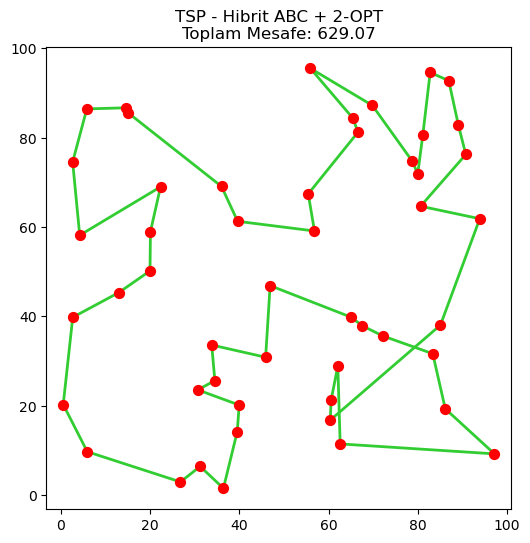

In [5]:
# Hibrit: Abc + 2opt
best_hybrid = two_opt(best_abc.copy(), cities)
plot_route(cities[best_hybrid], "TSP - Hibrit ABC + 2-OPT", line_color='limegreen')

In [6]:
# Mesafe karsilastirmasi
print("ABC Mesafesi:", distance(cities[best_abc]))
print("2-OPT Mesafesi:", distance(cities[best_2opt]))
print("Hibrit ABC+2OPT Mesafesi:", distance(cities[best_hybrid]))

ABC Mesafesi: 1581.6407821418507
2-OPT Mesafesi: 634.8077919469813
Hibrit ABC+2OPT Mesafesi: 629.0746421662994
